# 대만 월매출 신호 vs 한국/미국 T+n 주가수익률 검증

**질문**: 대만 M월 매출(M+1월 10일경 공시)의 YoY·가속도·서프라이즈가
관련 한국/미국 기업의 **이후 T+n 수익률**을 예측하는가?

**신호 3종** — `yoy`(수준), `d_yoy`(가속도 = YoY 변화), `surprise`(실제/모델 1개월 선행 예측 − 1)
**검증 3종** — ① Spearman IC (horizon별) ② 신호 분위별 평균 초과수익률 ③ 이벤트 스터디(-10~+40일)

주의: `pre_21d`(공시 전 21거래일 수익률)의 IC가 T+n 보다 크면
"주가가 이미 알고 있었다"는 뜻 → 예측 신호로 부적합.

In [19]:
import sys
from pathlib import Path

def find_project_root(marker="ODP", start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p] + list(p.parents):
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(f"'{marker}' 폴더를 찾지 못했습니다. 시작 위치: {p}")

ROOT = find_project_root("ODP")
MODULE_DIR = ROOT / "ODP" / "Taiwan_company_revenue_analysis"

for p in (str(ROOT), str(MODULE_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

print("ROOT       :", ROOT)
print("MODULE_DIR :", MODULE_DIR)

# ── 이제 두 스타일 모두 정상 동작 ──
from analysis_config import setup_universal_paths, find_revenue_db, make_engine
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

paths   = setup_universal_paths()
db      = find_revenue_db()
tw_conn = sqlite3.connect(str(db))
engine  = make_engine()

from ODP.Taiwan_company_revenue_analysis import signal_price_analysis as spa

ROOT       : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
MODULE_DIR : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\ODP\Taiwan_company_revenue_analysis
경로 설정 완료
프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA 폴더:    C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
[경로] revenue.db: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\ODP\Taiwan_Company\revenue.db


## 2. 주가 데이터 로드
시장조정용 벤치마크: 지수 데이터가 DB에 없으므로 기본은 **유니버스 중위수 프록시**.
⚠️ 종목 몇 개만 로드하면 프록시가 왜곡되므로, **비교 대상 + 충분히 넓은 유니버스**를 함께 로드하세요
(한국은 codes=None 으로 전 종목 로드 권장. 데이터가 크면 start 로 기간 제한).

In [20]:
# 한국: 전 종목 로드 (2019년 이후) — 프록시 안정성을 위해 넓게
kr_px = spa.load_kr_prices(engine, codes=None, start="2019-01-01")
print("한국 주가:", kr_px.shape, "|", kr_px.index.min().date(), "→", kr_px.index.max().date())

# 미국 (필요 시)
# us_px = spa.load_us_prices(engine, start="2019-01-01")
# print("미국 주가:", us_px.shape)

한국 주가: (1848, 3122) | 2019-01-02 → 2026-07-13


## 3. 페어 스캔 — 사전 지정한 관련 종목들만
상관분석(revenue_analysis)이나 업종 지식으로 **미리 정한** 후보만 스캔합니다.
전 종목 스캔은 다중비교로 '우연의 챔피언'을 만들므로 금지.

In [25]:
TW_CID   = "2408"                                  # 대만 신호 기업
KR_PAIRS = ["005930", "000660", "042700", "058470", "064760" ]  # ← 사전 지정 후보 ('A' 있어도 무방)
KR_PAIRS = [spa.norm_kr_code(c) for c in KR_PAIRS]

scan = spa.scan_pairs(tw_conn, TW_CID, kr_px, KR_PAIRS,
                      signal_col="d_yoy",   # yoy / d_yoy / surprise
                      horizon="T+21d")
scan

,ticker,IC,p,n,note
0,058470,0.352,0.002,76,
1,042700,0.225,0.051,76,
2,005930,0.218,0.058,76,
3,000660,0.192,0.097,76,
4,064760,0.171,0.139,76,


## 4. 단일 페어 정밀 검증 (IC / 분위 / 이벤트 스터디)

In [29]:
TARGET = "058470"    # ← 정밀 검증할 종목

res = spa.run_pair_study(tw_conn, TW_CID, kr_px, TARGET,
                         model="ensemble",
                         horizons=(5, 21, 42, 63),
                         use_market_adjust=True,
                         benchmark=None)      # 지수 컬럼이 있으면 지정
print("=== Spearman IC (행=신호, 열=측정구간) ===")
res["ic"]

=== Spearman IC (행=신호, 열=측정구간) ===


,pre_21d,T+5d,T+21d,T+42d,T+63d,n_obs
signal,,,,,,
d_yoy,0.027,0.08,0.352,0.339,0.401,77
surprise,NaN,NaN,NaN,NaN,NaN,0
yoy,0.097,-0.10,0.090,0.082,0.009,78


In [30]:
# === IC + p-value 함께 보기 (숫자형 컬럼만 사용) ===
from scipy.stats import spearmanr
import pandas as pd

def ic_pval_table(res: dict) -> pd.DataFrame:
    signals = res["signals"].select_dtypes(include="number")
    fwd     = res["fwd"].select_dtypes(include="number")

    rows = []
    for sig_col in signals.columns:
        row = {"signal": sig_col}
        for h_col in fwd.columns:
            pair = pd.concat([signals[sig_col], fwd[h_col]], axis=1).dropna()
            if len(pair) >= 3:
                ic, p = spearmanr(pair.iloc[:, 0], pair.iloc[:, 1])
            else:
                ic, p = float("nan"), float("nan")
            row[f"{h_col}_IC"] = round(ic, 3) if pd.notna(ic) else ic
            row[f"{h_col}_p"]  = round(p, 3) if pd.notna(p) else p
            row[f"{h_col}_n"]  = len(pair)
        rows.append(row)
    return pd.DataFrame(rows).set_index("signal")

print("=== IC + p-value + n (행=신호, 열=측정구간) ===")
ic_pval_table(res)

=== IC + p-value + n (행=신호, 열=측정구간) ===


,T+5d_IC,T+5d_p,T+5d_n,T+21d_IC,T+21d_p,T+21d_n,T+42d_IC,T+42d_p,T+42d_n,T+63d_IC,T+63d_p,T+63d_n,pre_21d_IC,pre_21d_p,pre_21d_n
signal,,,,,,,,,,,,,,,
yoy,-0.10,0.387,77,0.090,0.435,77,0.082,0.482,76,0.009,0.938,74,0.097,0.398,78
d_yoy,0.08,0.490,76,0.352,0.002,76,0.339,0.003,75,0.401,0.000,73,0.027,0.817,77
surprise,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0


In [24]:
# 신호 선택 후 분위 분석 (표본 적으면 q=3 유지)
SIG = "d_yoy"     # yoy / d_yoy / surprise
res.get(f"quantile_{SIG}", "표본 부족")

,T+5d,T+21d,T+42d,T+63d,T+5d hit%,T+21d hit%,T+42d hit%,T+63d hit%
Q1,1.39,3.80,10.33,24.58,38.0,50.0,62.0,69.0
Q2,4.77,7.49,17.29,31.20,72.0,60.0,64.0,76.0
Q3,3.11,11.44,19.48,22.93,73.0,62.0,62.0,58.0
Q_top-Q_bot,1.72,7.64,9.15,-1.65,NaN,NaN,NaN,NaN


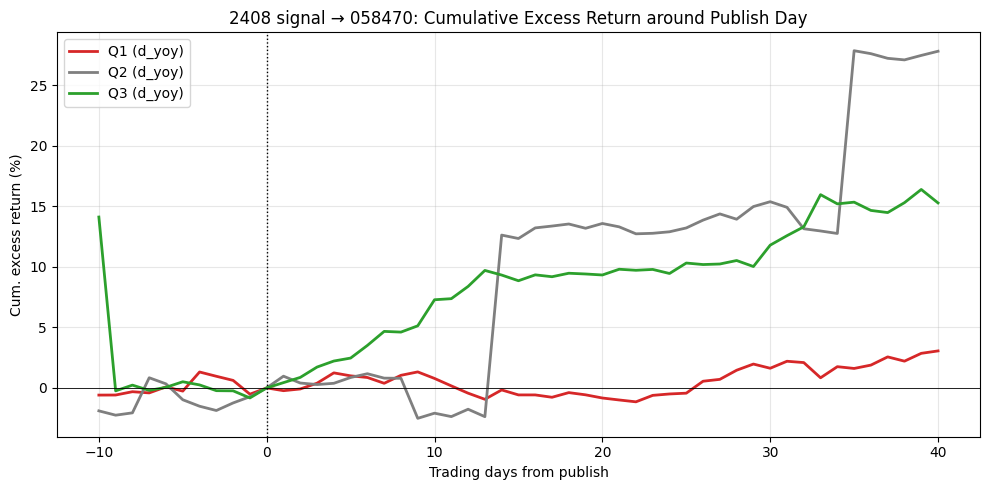

In [31]:
# 이벤트 스터디: 공시일 전후 누적 초과수익률 (신호 분위별)
ev = res.get(f"event_{SIG}")
if ev is not None and not ev.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Q1": "#d62728", "Q2": "#7f7f7f", "Q3": "#2ca02c"}
    for c in ev.columns:
        ax.plot(ev.index, ev[c], lw=2, color=colors.get(str(c), None), label=f"{c} ({SIG})")
    ax.axvline(0, color="k", ls=":", lw=1); ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{TW_CID} signal → {TARGET}: Cumulative Excess Return around Publish Day")
    ax.set_xlabel("Trading days from publish"); ax.set_ylabel("Cum. excess return (%)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

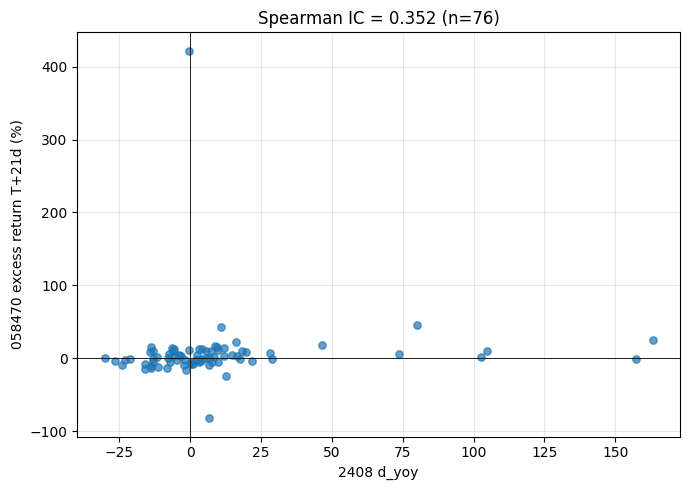

In [32]:
# 신호-수익률 산점 (IC 를 눈으로 확인)
H = "T+21d"
pair = pd.concat([res["signals"][SIG], res["fwd"][H]], axis=1).dropna()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pair.iloc[:, 0], pair.iloc[:, 1], s=28, alpha=0.7)
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel(f"{TW_CID} {SIG}"); ax.set_ylabel(f"{TARGET} excess return {H} (%)")
r = pair.iloc[:,0].rank().corr(pair.iloc[:,1].rank())
ax.set_title(f"Spearman IC = {r:.3f} (n={len(pair)})")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [33]:
# x=0 근처, y=400% 넘는 점이 어느 시점인지 확인
pair = pd.concat([res["signals"]["d_yoy"], res["fwd"]["T+21d"]], axis=1).dropna()
pair.columns = ["d_yoy", "fwd_T21d"]
outliers = pair[pair["fwd_T21d"].abs() > 100]
print(outliers)

               d_yoy    fwd_T21d
2022-11-01 -0.425463  421.991086


In [34]:
from scipy.stats import spearmanr

# 방법 1: 극단치 완전 제거
clean = pair[pair["fwd_T21d"].abs() <= 100]
ic, p = spearmanr(clean["d_yoy"], clean["fwd_T21d"])
print(f"아웃라이어 제외 IC = {ic:.3f}, p = {p:.3f}, n = {len(clean)}")

# 방법 2: winsorize (극단값을 상하한선으로 눌러줌, 표본 유지)
from scipy.stats.mstats import winsorize
import numpy as np
pair_w = pair.copy()
pair_w["fwd_T21d"] = winsorize(pair_w["fwd_T21d"], limits=[0.02, 0.02])
ic_w, p_w = spearmanr(pair_w["d_yoy"], pair_w["fwd_T21d"])
print(f"Winsorize 후 IC = {ic_w:.3f}, p = {p_w:.3f}")

아웃라이어 제외 IC = 0.367, p = 0.001, n = 75
Winsorize 후 IC = 0.352, p = 0.002


In [37]:
pair63 = pd.concat([res["signals"]["d_yoy"], res["fwd"]["T+63d"]], axis=1).dropna()
pair63.columns = ["d_yoy", "fwd_T63d"]
print(pair63[pair63["fwd_T63d"].abs() > 50].sort_values("fwd_T63d", ascending=False))

                 d_yoy    fwd_T63d
2022-09-01    0.118912  480.720667
2022-10-01   -3.153377  475.720663
2022-11-01   -0.425463  341.110351
2025-11-01  102.526006   76.681687
2025-12-01   79.970816   68.005645
2025-10-01  104.559854   56.682810
2025-02-01    3.842165  -82.811180
2025-03-01    6.678940  -83.985246
2025-01-01    0.898607  -86.011019


In [42]:
# ============================================================
# 검증 A: 겹치지 않는(non-overlapping) 표본으로 재검정
# ============================================================
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def ic_nonoverlap(signals: pd.DataFrame, fwd: pd.DataFrame, horizon_days: int, step_months: int):
    """horizon_days 만큼 겹치지 않도록 step_months 간격으로 표본을 솎아낸 뒤 IC 재계산."""
    signals = signals.select_dtypes(include="number")   # ← 추가: 숫자형 컬럼만
    fwd = fwd.select_dtypes(include="number")            # ← 추가: 숫자형 컬럼만

    rows = []
    for sig_col in signals.columns:
        pair = pd.concat([signals[sig_col], fwd[f"T+{horizon_days}d"]], axis=1).dropna()
        pair.columns = ["signal", "fwd"]
        pair = pair.sort_index()
        thinned = pair.iloc[::step_months]     # step_months 간격으로만 추출
        if len(thinned) >= 5:
            ic, p = spearmanr(thinned["signal"], thinned["fwd"])
        else:
            ic, p = np.nan, np.nan
        rows.append({"signal": sig_col, "n_original": len(pair),
                      "n_nonoverlap": len(thinned), "IC": round(ic, 3), "p": round(p, 3)})
    return pd.DataFrame(rows).set_index("signal")

print("=== T+21d (겹침 최소, 참고용 baseline) ===")
display(ic_nonoverlap(res["signals"], res["fwd"], horizon_days=21, step_months=1))

print("\n=== T+63d, step=1개월 (원본, 겹침 심함) ===")
display(ic_nonoverlap(res["signals"], res["fwd"], horizon_days=63, step_months=1))

print("\n=== T+63d, step=3개월 (겹치지 않도록 솎아냄) ===")
display(ic_nonoverlap(res["signals"], res["fwd"], horizon_days=63, step_months=3))

=== T+21d (겹침 최소, 참고용 baseline) ===


,n_original,n_nonoverlap,IC,p
signal,,,,
yoy,77,77,0.090,0.435
d_yoy,76,76,0.352,0.002
surprise,0,0,NaN,NaN



=== T+63d, step=1개월 (원본, 겹침 심함) ===


,n_original,n_nonoverlap,IC,p
signal,,,,
yoy,74,74,0.009,0.938
d_yoy,73,73,0.401,0.000
surprise,0,0,NaN,NaN



=== T+63d, step=3개월 (겹치지 않도록 솎아냄) ===


,n_original,n_nonoverlap,IC,p
signal,,,,
yoy,74,25,-0.030,0.887
d_yoy,73,25,0.407,0.044
surprise,0,0,NaN,NaN


In [40]:
# ============================================================
# 검증 B: Newey-West 자기상관 보정 표준오차로 유의성 재계산
# statsmodels 필요 (pip install statsmodels --break-system-packages 로 설치되어 있어야 함)
# ============================================================
import statsmodels.api as sm

def newey_west_ic_test(signals: pd.DataFrame, fwd: pd.DataFrame, horizon_col: str, maxlags: int):
    """
    IC(순위상관) 자체엔 NW 보정을 직접 적용하기 어려우므로,
    signal(순위)과 fwd(순위)를 회귀 형태로 놓고 NW 표준오차로 유의성을 다시 검정.
    -> 결과 해석: '기존 spearmanr p-value'보다 훨씬 보수적인(더 큰) p-value가 나오는 게 정상.
    """
    rows = []
    for sig_col in signals.columns:
        pair = pd.concat([signals[sig_col], fwd[horizon_col]], axis=1).dropna()
        pair.columns = ["signal", "fwd"]
        if len(pair) < 5:
            rows.append({"signal": sig_col, "beta": np.nan, "p_NW": np.nan, "n": len(pair)})
            continue

        # 순위로 변환 (Spearman과 동일한 전처리)
        x_rank = pair["signal"].rank()
        y_rank = pair["fwd"].rank()

        X = sm.add_constant(x_rank)
        model = sm.OLS(y_rank, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
        beta = model.params["signal"]
        p_nw = model.pvalues["signal"]
        rows.append({"signal": sig_col, "beta": round(beta, 3),
                      "p_NW": round(p_nw, 4), "n": len(pair)})
    return pd.DataFrame(rows).set_index("signal")

# maxlags: T+21d(1개월)는 lag=1, T+63d(3개월)는 lag=3 정도로 겹침 구간 수만큼 설정
print("=== T+21d, Newey-West 보정 (maxlags=1) ===")
display(newey_west_ic_test(res["signals"], res["fwd"], "T+21d", maxlags=1))

print("\n=== T+63d, Newey-West 보정 (maxlags=3) ===")
display(newey_west_ic_test(res["signals"], res["fwd"], "T+63d", maxlags=3))

=== T+21d, Newey-West 보정 (maxlags=1) ===


,beta,p_NW,n
signal,,,
yoy,0.090,0.4844,77
d_yoy,0.352,0.0003,76
surprise,NaN,NaN,0
publish,-0.029,0.8108,77



=== T+63d, Newey-West 보정 (maxlags=3) ===


,beta,p_NW,n
signal,,,
yoy,0.009,0.9572,74
d_yoy,0.401,0.0002,73
surprise,NaN,NaN,0
publish,0.061,0.7161,74


In [41]:
# ============================================================
# 검증 C: 극단치 클러스터(연속월) 자동 탐지
# — 어떤 horizon에서 몇 개월 연속 극단치가 뭉쳐있는지 한눈에 확인
# ============================================================
def find_clustered_outliers(signals: pd.DataFrame, fwd: pd.DataFrame, horizon_col: str,
                             sig_col: str = "d_yoy", threshold: float = 50.0):
    pair = pd.concat([signals[sig_col], fwd[horizon_col]], axis=1).dropna()
    pair.columns = ["signal", "fwd"]
    pair = pair.sort_index()

    outliers = pair[pair["fwd"].abs() > threshold].copy()
    outliers["match_direction"] = np.sign(outliers["signal"]) == np.sign(outliers["fwd"])

    # 연속월 클러스터 탐지 (월 인덱스 차이가 1개월 이내인 그룹 찾기)
    idx = outliers.index.to_series()
    gap_months = idx.diff().dt.days.fillna(999) / 30
    outliers["cluster_id"] = (gap_months > 1.5).cumsum()

    cluster_sizes = outliers.groupby("cluster_id").size()
    outliers["cluster_size"] = outliers["cluster_id"].map(cluster_sizes)

    return outliers[["signal", "fwd", "match_direction", "cluster_size"]]

print(f"=== T+63d 극단치(|fwd|>50%) 클러스터 분석 ===")
result_c = find_clustered_outliers(res["signals"], res["fwd"], "T+63d", sig_col="d_yoy", threshold=50)
display(result_c)

n_clustered = (result_c["cluster_size"] >= 2).sum()
print(f"\n연속월 클러스터에 속한 극단치: {n_clustered}개 / 전체 극단치 {len(result_c)}개")
print(f"신호 방향 불일치(match_direction=False): {(~result_c['match_direction']).sum()}개")

=== T+63d 극단치(|fwd|>50%) 클러스터 분석 ===


,signal,fwd,match_direction,cluster_size
2022-09-01,0.118912,480.720667,True,3
2022-10-01,-3.153377,475.720663,False,3
2022-11-01,-0.425463,341.110351,False,3
2025-01-01,0.898607,-86.011019,False,3
2025-02-01,3.842165,-82.811180,False,3
2025-03-01,6.678940,-83.985246,False,3
2025-10-01,104.559854,56.682810,True,3
2025-11-01,102.526006,76.681687,True,3
2025-12-01,79.970816,68.005645,True,3



연속월 클러스터에 속한 극단치: 9개 / 전체 극단치 9개
신호 방향 불일치(match_direction=False): 5개


## 5. 결과 해석 가이드
- **IC**: |IC|≥0.2 & p<0.05 & n≥40 이면 주목. `pre_21d` IC가 T+n 보다 크면 주가 선행(신호 무효).
- **분위**: Q_top−Q_bot 스프레드가 horizon 이 길어질수록 커지면 정보 확산형 패턴.
- **이벤트 스터디**: 분위 간 경로가 day 0 이후 벌어지고 day<0 에서 평행하면 이상적.
- 월간 표본 ~70개 + 겹치는 horizon → p값은 과신 금지. 서로 다른 페어 2~3개에서
  같은 방향이 재현되는지가 더 중요한 증거.

In [11]:
tw_conn.close(); engine.dispose()